## Imports

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Structure and shape

In [63]:
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

In [64]:
test.shape[0]

418

In [65]:

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [66]:
train.shape[0]

891

In [67]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [69]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


### Pre Processing

In [70]:
test.drop(columns=['Cabin'],inplace=True)

In [71]:
train.drop(columns=['Cabin'],inplace=True)

In [72]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [73]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

In [74]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [75]:
train['Embarked'] = train['Embarked'].fillna('S')

In [76]:
train['Embarked'].isnull().sum()

np.int64(0)

In [77]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [78]:
train['Fare'] = train['Fare'].fillna(train['Fare'].mean())

In [79]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [80]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [81]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

In [82]:
train_Age=np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std(),177)

In [83]:
test_Age=np.random.randint(test['Age'].mean()-test['Age'].std(),test['Age'].mean()+test['Age'].std(),177)

In [84]:
print(train_Age)

[36 40 30 29 18 27 31 32 18 19 26 21 36 23 30 43 35 41 32 39 40 16 33 42
 30 23 27 36 20 19 32 43 42 19 18 17 19 34 27 15 43 15 30 40 43 15 41 26
 30 36 25 15 15 33 41 32 22 38 23 16 32 31 33 39 36 24 18 27 40 25 20 26
 27 28 22 40 43 17 36 15 37 21 31 42 38 15 42 39 15 35 22 21 35 31 35 30
 20 36 43 36 37 31 37 23 36 34 33 16 29 36 17 28 18 15 18 34 34 26 29 27
 18 41 20 39 29 15 30 36 23 24 26 22 26 33 32 16 15 28 36 16 42 34 26 35
 36 17 25 15 41 32 40 32 17 22 32 41 21 27 33 42 28 22 15 35 36 24 24 32
 33 19 17 16 32 18 34 18 31]


In [85]:
print(test_Age)

[35 36 30 19 25 39 38 28 42 20 16 25 24 35 24 31 16 33 41 31 42 22 43 29
 37 20 43 23 41 16 31 20 22 34 33 16 35 27 35 39 25 36 37 43 36 29 30 20
 28 25 27 30 30 29 42 31 28 36 36 24 23 30 36 19 25 35 16 41 43 42 41 40
 36 35 19 31 17 29 35 33 31 18 27 28 24 29 30 42 20 25 34 26 25 33 41 23
 27 28 29 25 41 30 22 38 43 34 39 21 39 19 31 31 24 24 23 36 41 21 43 29
 30 32 35 24 19 32 28 37 38 43 21 32 23 22 27 30 18 18 28 22 19 29 22 17
 28 36 36 24 43 20 31 28 26 37 20 29 31 17 37 38 39 32 35 36 26 25 24 24
 40 40 30 30 25 34 34 43 39]


In [86]:

train.loc[train['Age'].isnull(),'Age']=train_Age.mean()

In [87]:
test.loc[test['Age'].isnull(),'Age']=test_Age.mean()

In [88]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [89]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## EDA

In [90]:
def Survive_ratio(train, x):
    return train[train['Pclass']==x]['Survived'].value_counts()
for i in range(1,4):
    print(Survive_ratio(train, i))

Survived
1    136
0     80
Name: count, dtype: int64
Survived
0    97
1    87
Name: count, dtype: int64
Survived
0    372
1    119
Name: count, dtype: int64


In [91]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [92]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [93]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

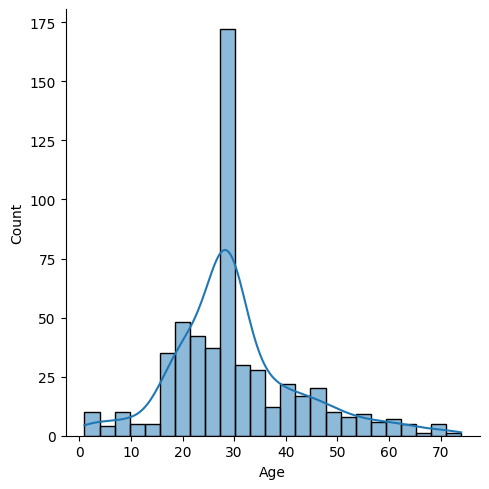

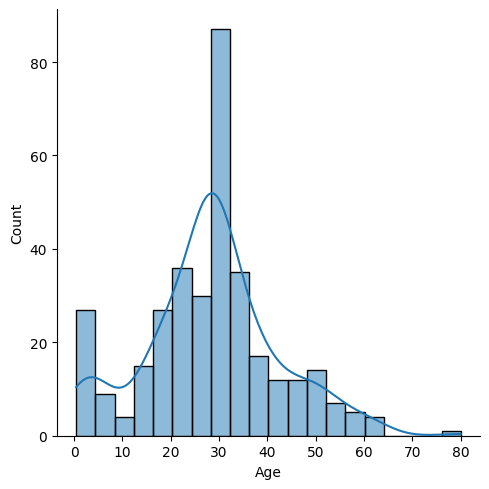

In [94]:
sns.displot(train['Age'][train['Survived']==0],kde=True)
sns.displot(train['Age'][train['Survived']==1],kde=True)

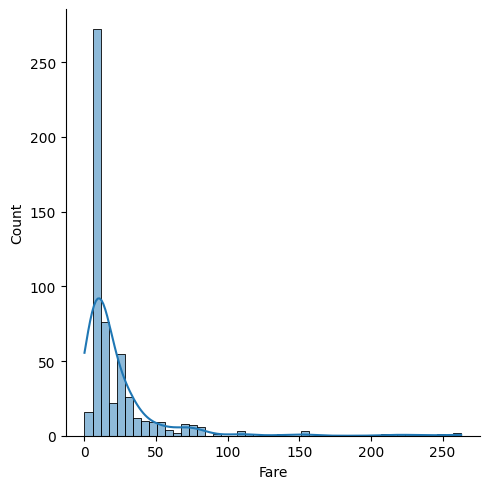

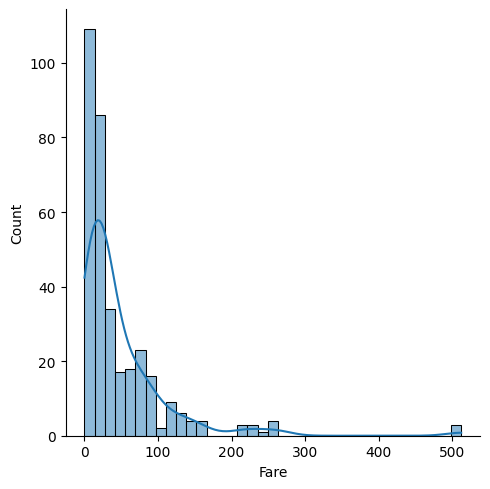

In [95]:
sns.displot(train['Fare'][train['Survived']==0],kde=True)
sns.displot(train['Fare'][train['Survived']==1],kde=True)

In [96]:
train.drop(columns=['Ticket'],inplace=True)
test.drop(columns=['Ticket'],inplace=True)

In [97]:
train['family_size']=train['SibSp']+train['Parch']+1

In [98]:
train['family_size'].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [99]:
test['family_size']=test['SibSp']+test['Parch']+1

In [100]:
test['family_size'].value_counts()

family_size
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [101]:
train.groupby(['family_size'])['Survived'].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [102]:
def calculate(num):
    if num==1:
        return "Alone"
    elif num>1 and num<5:
        return "Medium"
    else:
        return "Large"

In [103]:

train['Family_size_category']=train['family_size'].apply(calculate)

In [104]:
train['Family_size_category'].value_counts()

Family_size_category
Alone     537
Medium    292
Large      62
Name: count, dtype: int64

In [105]:
test['Family_size_category']=test['family_size'].apply(calculate)

In [106]:
test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,family_size,Family_size_category
0,892,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q,1,Alone
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S,2,Medium


In [107]:
train.drop(columns=['SibSp','Parch','family_size'],inplace=True)
test.drop(columns=['SibSp','Parch','family_size'],inplace=True)

In [108]:
print(train.shape)
print(test.shape)

(891, 9)
(418, 8)


In [109]:
passenger_id=test['PassengerId'].values

In [110]:
train.drop(columns=['PassengerId','Name'],inplace=True)
test.drop(columns=['PassengerId','Name'],inplace=True)

In [111]:
train.shape

(891, 7)

In [112]:
train=pd.get_dummies(train,columns=['Pclass','Sex','Embarked','Family_size_category'],drop_first=True)

In [113]:
train.shape

(891, 10)

In [115]:
test=pd.get_dummies(test,columns=['Pclass','Sex','Embarked','Family_size_category'],drop_first=True)

In [116]:
test.shape

(418, 9)

In [117]:
x=train.iloc[:,1:].values
y=train.iloc[:,0].values

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
df.iloc[]